# Bingham Filter — 2D Axis Estimation
Exploring the implementation of Kurz et al. (2014)

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))


import numpy as np
import matplotlib.pyplot as plt
from spatial_nav.bingham_filter import *


The Bingham PDF.
How does z1 (concentration parameter) change the shape of the distribution?

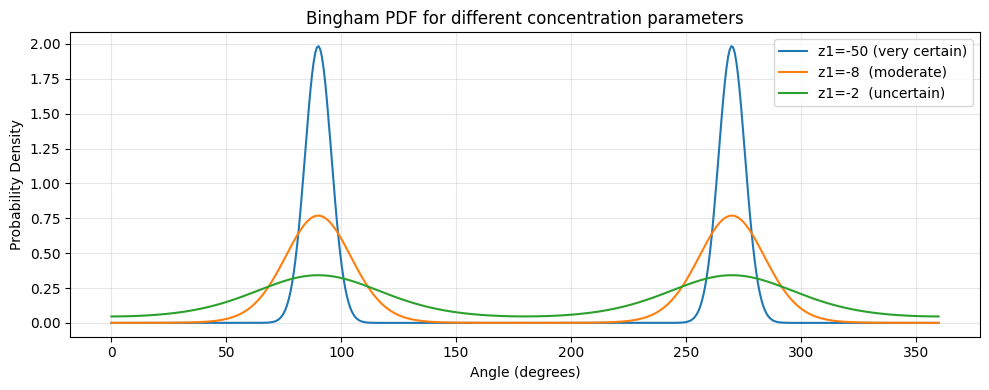

In [2]:
thetas = np.linspace(0, 2 * np.pi, 500)

fig, ax = plt.subplots(figsize=(10, 4))

for z1, label in [(-50, 'z1=-50 (very certain)'),
                  (-8,  'z1=-8  (moderate)'),
                  (-2,  'z1=-2  (uncertain)')]:
    b = BinghamDistribution(np.eye(2), np.diag([z1, 0.0]))
    pdf_vals = [b.pdf(t) for t in thetas]
    ax.plot(np.degrees(thetas), pdf_vals, label=label)

ax.set_xlabel('Angle (degrees)')
ax.set_ylabel('Probability Density')
ax.set_title('Bingham PDF for different concentration parameters')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

One Cycle
Stepping through a single timestep manually.

In [6]:
estimate  = BinghamDistribution(np.eye(2), np.diag([-20.0, 0.0]))
sys_noise = BinghamDistribution(np.array([[0.,1.],[1.,0.]]), np.diag([-50.0, 0.0]))
meas_noise = BinghamDistribution(np.array([[0.,1.],[1.,0.]]), np.diag([-2.0, 0.0]))
measurement = np.array([1.0, 0.0])

predicted = predict(estimate, sys_noise)
updated   = update(predicted, meas_noise, measurement)

print(f'Before predict:  z1 = {estimate.z1:.2f}')
print(f'After  predict:  z1 = {predicted.z1:.2f}  (less negative = noise spread the distribution)')
print(f'After  update:   z1 = {updated.z1:.2f}')
print(f'Updated mode: {np.degrees(updated.mode_angle):.1f} degrees')

Before predict:  z1 = -20.00
After  predict:  z1 = -14.74  (less negative = noise spread the distribution)
After  update:   z1 = -12.74
Updated mode: 90.0 degrees


In [ ]:
def angular_error(x_true, x_est):
    # Respects 180 degree symmetry
    dot = np.clip(abs(np.dot(x_true, x_est)), 0.0, 1.0)
    angle = np.arccos(dot)
    return min(angle, np.pi - angle)

def simulate_paper_scenario(n_steps=100, n_runs=10, noise_type='bingham'):
    # Paper Section 7.1 setup
    # Initial estimate 90 degrees wrong. Tests recovery from poor initialisation
    initial_estimate = BinghamDistribution(np.eye(2), np.diag([-1.0, 0.0]))
    sys_noise  = BinghamDistribution(np.array([[0.,1.],[1.,0.]]), np.diag([-200.0, 0.0]))
    meas_noise = BinghamDistribution(np.array([[0.,1.],[1.,0.]]), np.diag([-2.0,   0.0]))
    x_true_0   = np.array([1.0, 0.0])
    all_errors = []

    for _ in range(n_runs):
        true_states = []
        x_true = x_true_0.copy()
        for _ in range(n_steps):
            angle = np.arctan2(x_true[1], x_true[0])
            angle += np.random.normal(0, np.radians(2.9))
            x_true = np.array([np.cos(angle), np.sin(angle)])
            true_states.append(x_true.copy())

        measurements = []
        for x in true_states:
            if noise_type == 'bingham':
                noise_angle = np.random.vonmises(0, -meas_noise.z1 / 2)
            else:
                noise_angle = np.random.normal(0, np.radians(36.3))
            angle = np.arctan2(x[1], x[0]) + noise_angle
            measurements.append(np.array([np.cos(angle), np.sin(angle)]))

        estimates = run_bingham_filter(initial_estimate, sys_noise, meas_noise, measurements)
        errors    = [angular_error(true_states[k], estimates[k].mode) for k in range(n_steps)]
        all_errors.append(errors)

    return np.array(all_errors)


def rmse(errors):
    return np.sqrt(np.mean(np.array(errors)**2))

4. Full Filter, reproducing the kurz results

Overall RMSE:      38.77 degrees
Mean final error:  24.65 degrees


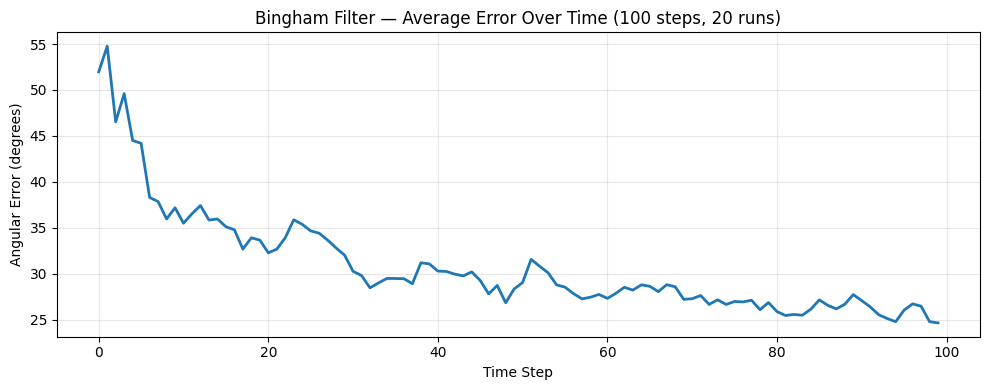

In [12]:
all_errors = simulate_paper_scenario(n_steps=100, n_runs=100, noise_type='bingham')

print(f'Overall RMSE:      {np.degrees(rmse(all_errors.flatten())):.2f} degrees')
print(f'Mean final error:  {np.degrees(np.mean(all_errors[:, -1])):.2f} degrees')

mean_errors = np.mean(all_errors, axis=0)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(np.degrees(mean_errors), linewidth=2)
ax.set_xlabel('Time Step')
ax.set_ylabel('Angular Error (degrees)')
ax.set_title('Bingham Filter — Average Error Over Time (100 steps, 20 runs)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()